# X-VLA WidowX Trajectory Visualization

Run X-VLA inference on a simulated WidowX 250s robot in MuJoCo.
The model predicts end-effector trajectories for a specified task,
visualized as colored dots in the camera views.

**Requirements:** GPU runtime recommended (T4 is sufficient), but CPU is fine for this.

In [ ]:
import os

# If assets/ exists locally, we're already in the repo root — skip cloning
if not os.path.exists('assets'):
    print("Assuming Colab")
    %cd /content
    !git clone --depth 1 -b ipynb https://github.com/avikde/vla-pipeline.git || echo "Already cloned"
    %cd vla-pipeline

    # Install dependencies
    %pip install -q "lerobot[xvla]" mujoco Pillow
    # NOTE: Do this if lerobot insists on installing torch 2.7.1+cpu
    # %pip uninstall torch torchvision -y && pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128

In [3]:
import sys

# Use EGL for headless OpenGL rendering (Colab/Linux servers without display)
# Skip on Windows/macOS where native windowing is available
if sys.platform == 'linux' and 'DISPLAY' not in os.environ:
    os.environ['MUJOCO_GL'] = 'egl'

import mujoco
import numpy as np
import torch
import matplotlib.pyplot as plt

print(f"MuJoCo: {mujoco.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
# print(f"MUJOCO_GL: {os.environ.get('MUJOCO_GL', 'default')}")

MuJoCo: 3.5.0
PyTorch: 2.10.0+cu128
CUDA available: False


### 1. Load X-VLA Policy (will take some time to download ~4GB the first time)

In [4]:
from lerobot.policies.xvla.modeling_xvla import XVLAPolicy
from transformers import AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
policy = XVLAPolicy.from_pretrained("lerobot/xvla-widowx").to(device).eval()
tokenizer = AutoTokenizer.from_pretrained(policy.config.tokenizer_name)

print(f"Device: {device}")
print(f"Action mode: {policy.config.action_mode}")
print(f"Chunk size: {policy.config.chunk_size}")
print(f"N action steps: {policy.config.n_action_steps}")

c:\Users\avik\Documents\vla-pipeline\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Florence2ForConditionalGeneration has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception

Device: cpu
Action mode: ee6d
Chunk size: 30
N action steps: 30


### 2. Load MuJoCo Scene

In [5]:
xml_path = 'assets/widowx/widowx_vision_scene.xml'
mj_model = mujoco.MjModel.from_xml_path(xml_path)
mj_data = mujoco.MjData(mj_model)

# Initialize to home pose (avoids finger collision at qpos=0)
home_qpos = mj_model.keyframe('home').qpos
n_robot_joints = 8  # 6 arm + 2 finger
mj_data.qpos[:n_robot_joints] = home_qpos[:n_robot_joints]
mj_data.ctrl[:] = mj_model.keyframe('home').ctrl
mujoco.mj_forward(mj_model, mj_data)

# Settle physics
for _ in range(100):
    mujoco.mj_step(mj_model, mj_data)

print(f"Model loaded: nq={mj_model.nq}, nv={mj_model.nv}, nu={mj_model.nu}")

Model loaded: nq=15, nv=14, nu=7


### 3. Helper Functions

In [6]:
VLA_WIDTH, VLA_HEIGHT = 256, 256
mj_model.vis.global_.offwidth = max(mj_model.vis.global_.offwidth, VLA_WIDTH)
mj_model.vis.global_.offheight = max(mj_model.vis.global_.offheight, VLA_HEIGHT)
renderer = mujoco.Renderer(mj_model, height=VLA_HEIGHT, width=VLA_WIDTH)

# Trajectory marker colors (green -> red gradient)
NUM_MARKERS = 10
MARKER_COLORS = []
for i in range(NUM_MARKERS):
    fade = i / max(1, NUM_MARKERS - 1)
    MARKER_COLORS.append(np.array([fade, 1.0 - fade, 0.0, 0.6], dtype=np.float32))


def render_camera(camera_name, trajectory=None):
    """Render from a camera, optionally with trajectory spheres."""
    camera_id = mj_model.camera(camera_name).id
    renderer.update_scene(mj_data, camera=camera_id)
    if trajectory:
        for i, target_xyz in enumerate(trajectory):
            mujoco.mjv_initGeom(
                renderer.scene.geoms[renderer.scene.ngeom],
                type=mujoco.mjtGeom.mjGEOM_SPHERE,
                size=[0.005, 0, 0],
                pos=target_xyz.astype(np.float64),
                mat=np.eye(3).flatten(),
                rgba=MARKER_COLORS[i],
            )
            renderer.scene.ngeom += 1
    return renderer.render()


def preprocess_image(rgb_image, device='cpu'):
    img_tensor = torch.from_numpy(rgb_image).permute(2, 0, 1).float() / 255.0
    return img_tensor.unsqueeze(0).to(device)


def get_ee_pose():
    ee_body_id = mj_model.body("wx250s/gripper_link").id
    return mj_data.xpos[ee_body_id].copy(), mj_data.xmat[ee_body_id].reshape(3, 3).copy()


def rotation_matrix_to_euler(rot_mat):
    sy = np.sqrt(rot_mat[0, 0]**2 + rot_mat[1, 0]**2)
    if sy > 1e-6:
        roll = np.arctan2(rot_mat[2, 1], rot_mat[2, 2])
        pitch = np.arctan2(-rot_mat[2, 0], sy)
        yaw = np.arctan2(rot_mat[1, 0], rot_mat[0, 0])
    else:
        roll = np.arctan2(-rot_mat[1, 2], rot_mat[1, 1])
        pitch = np.arctan2(-rot_mat[2, 0], sy)
        yaw = 0.0
    return roll, pitch, yaw


def get_ee_state_8d():
    """8D EE state matching BridgeData: [x, y, z, roll, pitch, yaw, pad, gripper]"""
    ee_pos, ee_rot = get_ee_pose()
    roll, pitch, yaw = rotation_matrix_to_euler(ee_rot)
    gripper_pos = mj_data.qpos[mj_model.joint("left_finger").id]
    return np.array([ee_pos[0], ee_pos[1], ee_pos[2],
                     roll, pitch, yaw, 0.0, gripper_pos], dtype=np.float32)


def get_cube_position(cube_name="red_block"):
    try:
        return mj_data.xpos[mj_model.body(cube_name).id].copy()
    except Exception:
        return None


print("Helpers ready.")

Helpers ready.


### 4. Run Inference

**Specify the task below 👇**

In [7]:
task_instruction = "Pick up the red block" # 👈 Edit here

tokenized = tokenizer(
    task_instruction,
    padding='max_length',
    max_length=policy.config.tokenizer_max_length,
    truncation=True,
    return_tensors='pt'
)
language_tokens = tokenized['input_ids'].to(device)
language_attention_mask = tokenized['attention_mask'].to(device)

# Initial state
ee_pos, _ = get_ee_pose()
cube_pos = get_cube_position()
print(f"Task: '{task_instruction}'")
print(f"EE position: {ee_pos}")
print(f"Cube position: {cube_pos}")
print(f"Distance: {np.linalg.norm(ee_pos - cube_pos):.3f}m")

Task: 'Pick up the red block'
EE position: [ 1.58816596e-01 -1.21958531e-06  2.28693613e-01]
Cube position: [0.25       0.1        0.01989198]
Distance: 0.249m


In [10]:
# Run inference until we get the first action chunk
cached_action_targets = []
step = 0

while len(cached_action_targets) == 0:
    img = render_camera('up')
    img2 = render_camera('side')

    img_tensor = preprocess_image(img, device=device)
    img2_tensor = preprocess_image(img2, device=device)
    ee_state_8d = get_ee_state_8d()

    observation = {
        'observation.images.image': img_tensor,
        'observation.images.image2': img2_tensor,
        'observation.state': torch.from_numpy(ee_state_8d).float().unsqueeze(0).to(device),
        'observation.language.tokens': language_tokens,
        'observation.language.attention_mask': language_attention_mask,
    }

    with torch.inference_mode():
        actions = policy.select_action(observation)

    # Check if a new chunk was generated
    action_queue = policy._queues.get("action", [])
    queue_size = len(action_queue)
    is_new_chunk = queue_size == policy.config.chunk_size - 1

    if is_new_chunk:
        for queued_action in list(action_queue)[:NUM_MARKERS]:
            if isinstance(queued_action, torch.Tensor):
                cached_action_targets.append(queued_action.flatten()[:3].cpu().numpy())
            else:
                cached_action_targets.append(np.array(queued_action).flatten()[:3])

    mujoco.mj_step(mj_model, mj_data)
    step += 1
    print(f"Step {step}, queue: {queue_size}", end='\r')

actions_np = actions.detach().cpu().numpy().flatten()
print(f"\nFirst chunk generated at step {step}")
print(f"Cached {len(cached_action_targets)} trajectory targets")
print(f"Action vector (20D): {np.array2string(actions_np, precision=4, suppress_small=True)}")

Step 30, queue: 29
First chunk generated at step 30
Cached 10 trajectory targets
Action vector (20D): [ 0.1661 -0.0009  0.231   0.0288  0.9606 -0.9492  0.0343 -0.0077 -0.0733
  0.0389 -0.0003 -0.0001  0.0002 -0.0005  0.0003 -0.0001 -0.0005  0.0003
 -0.0002  0.    ]


### 5. Visualize Results

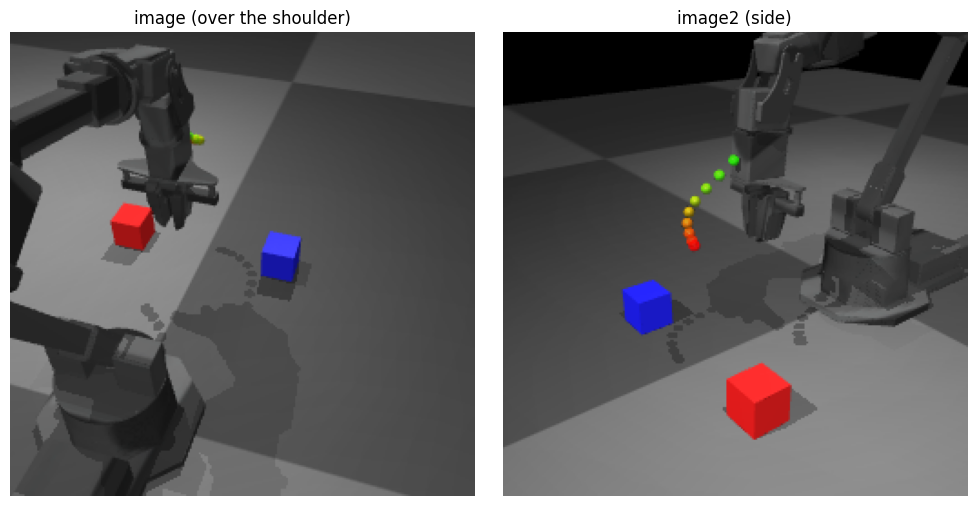


Current EE: [ 1.5869e-01 -1.5962e-06  2.2827e-01]
Cube:       [0.25   0.1    0.0199]

Predicted trajectory (first 10 targets):
  [0] [ 0.1791 -0.0006  0.2216]  dist to cube: 0.2362m
  [1] [ 0.2014 -0.0008  0.2052]  dist to cube: 0.2165m
  [2] [ 0.2162 -0.0027  0.1933]  dist to cube: 0.2044m
  [3] [ 0.2295 -0.0048  0.1828]  dist to cube: 0.1948m
  [4] [ 0.242  -0.0046  0.1735]  dist to cube: 0.1860m
  [5] [0.2523 0.0008 0.1671]  dist to cube: 0.1775m
  [6] [0.2599 0.0095 0.161 ]  dist to cube: 0.1680m
  [7] [0.2638 0.0184 0.1558]  dist to cube: 0.1591m
  [8] [0.2658 0.0257 0.1517]  dist to cube: 0.1522m
  [9] [0.267  0.0309 0.1496]  dist to cube: 0.1479m


In [11]:
traj = cached_action_targets
W, H = VLA_WIDTH, VLA_HEIGHT

snap_up = render_camera('up', trajectory=traj)
snap_side = render_camera('side', trajectory=traj)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, img, title in zip(axes,
    [snap_up, snap_side],
    ['image (over the shoulder)', 'image2 (side)']):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Print trajectory info
ee_pos, _ = get_ee_pose()
cube_pos = get_cube_position()
print(f"\nCurrent EE: {np.array2string(ee_pos, precision=4)}")
print(f"Cube:       {np.array2string(cube_pos, precision=4)}")
print(f"\nPredicted trajectory (first {len(traj)} targets):")
for i, t in enumerate(traj):
    dist = np.linalg.norm(t - cube_pos) if cube_pos is not None else 0
    print(f"  [{i}] {np.array2string(t, precision=4)}  dist to cube: {dist:.4f}m")